**Dataset:** Daily weather observations - Raleigh-Durham International Airport  
**Source:** NOAA, 2022–2026  
**Cleaned Data:** 1,477 clean rows

| Variable | Description | Unit | Role |
|----------|-------------|------|------|
| X1 | TMAX — Max daily temperature | °F | Input |
| X2 | TMIN — Min daily temperature | °F | Input |
| X3 | PRCP — Daily precipitation | inches | Input |
| X4 | AWND — Avg wind speed | mph | Input |
| X5 | SNOW — Daily snowfall | inches | Input |
| Y  | TAVG — Avg daily temperature | °F | **Output** |

# Task 2: Simple Moving Average
**Dataset:** TAVG daily temperature - Raleigh-Durham Airport, NOAA 2022–2026


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import probplot
from statsmodels.tsa.stattools import adfuller, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Load data
df = pd.read_csv('weather_clean.csv')
y  = df['Y'].values.astype(float)
n  = len(y)

dates    = pd.date_range(start='2022-01-01', periods=n, freq='D')
ts       = pd.Series(y, index=dates, name='TAVG (°F)')
train_n  = int(n * 0.8)
ts_train = ts.iloc[:train_n]
ts_test  = ts.iloc[train_n:]
train_vals = ts_train.values
test_vals  = ts_test.values

print(f'Total: {n} | Train: {len(ts_train)} | Test: {len(ts_test)}')

# Helper functions
def rmse(actual, predicted):
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted))**2))

def mape(actual, predicted):
    a, p = np.array(actual), np.array(predicted)
    mask = a != 0
    return np.mean(np.abs((a[mask] - p[mask]) / a[mask])) * 100

def chi2_normality_test(residuals, n_bins=20):
    observed, bin_edges = np.histogram(residuals, bins=n_bins)
    expected = np.array([
        len(residuals) * (
            stats.norm.cdf(bin_edges[i+1], residuals.mean(), residuals.std()) -
            stats.norm.cdf(bin_edges[i],   residuals.mean(), residuals.std())
        ) for i in range(n_bins)
    ])
    mask  = expected >= 5
    obs_f = observed[mask]
    exp_f = expected[mask]
    exp_f = exp_f * (obs_f.sum() / exp_f.sum())
    chi2_s, p_val = stats.chisquare(obs_f, f_exp=exp_f)
    return chi2_s, p_val, mask.sum()-1-2, observed, expected, bin_edges

# SMA and Exp Smoothing helpers (needed in Tasks 2, 3, 5)
# Using k-day moving average to smooth short-term variability in weather patterns
# Small k (e.g. 7) captures weekly patterns; large k (e.g. 30) reveals seasonal trend
def sma_predict(series, k):
    predicted = np.full(len(series), np.nan)
    for t in range(k, len(series)):
        predicted[t] = np.mean(series[t-k:t])
    return predicted

def exp_smooth_predict(series, alpha):
    pred = np.full(len(series), np.nan)
    pred[0] = series[0]
    for t in range(1, len(series)):
        pred[t] = alpha * series[t-1] + (1 - alpha) * pred[t-1]
    return pred


Total: 1477 | Train: 1181 | Test: 296


## Tasks 2.1–2.4 - Fit SMA for k = 1 to 30, Select Best k

Best k by RMSE : k=1  RMSE=5.8021°F
Best k by MAPE : k=1  MAPE=8.1489%


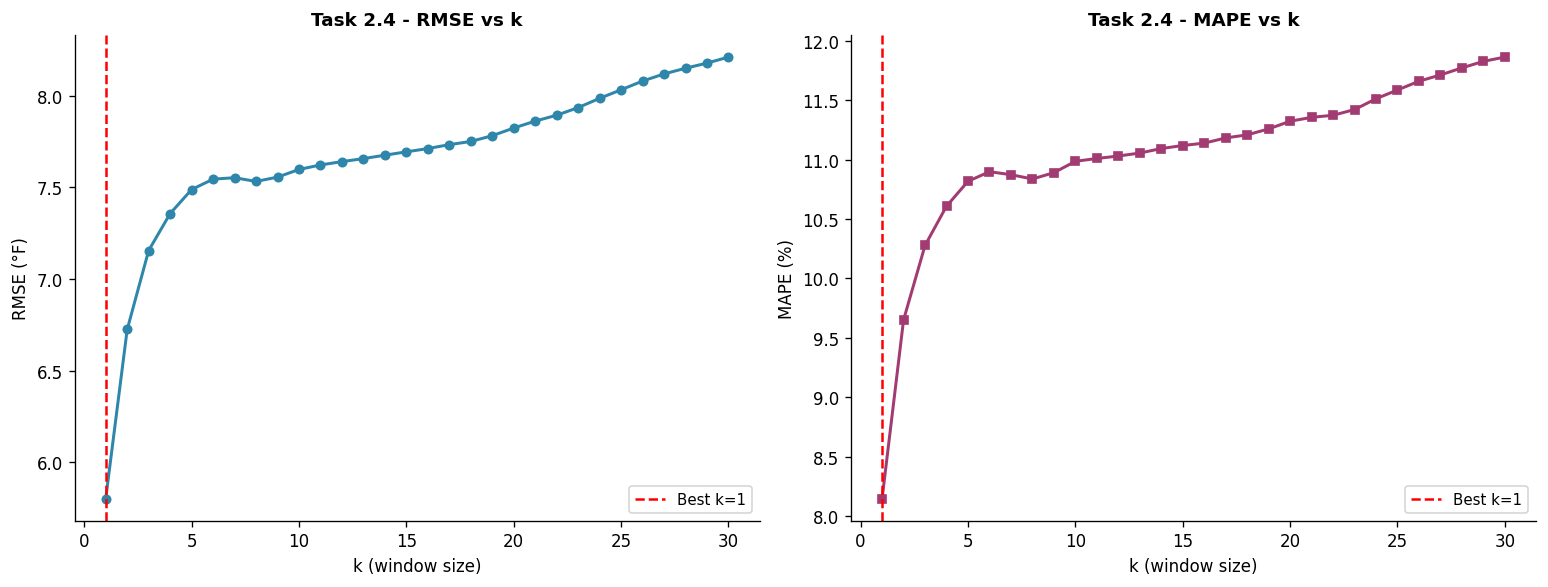

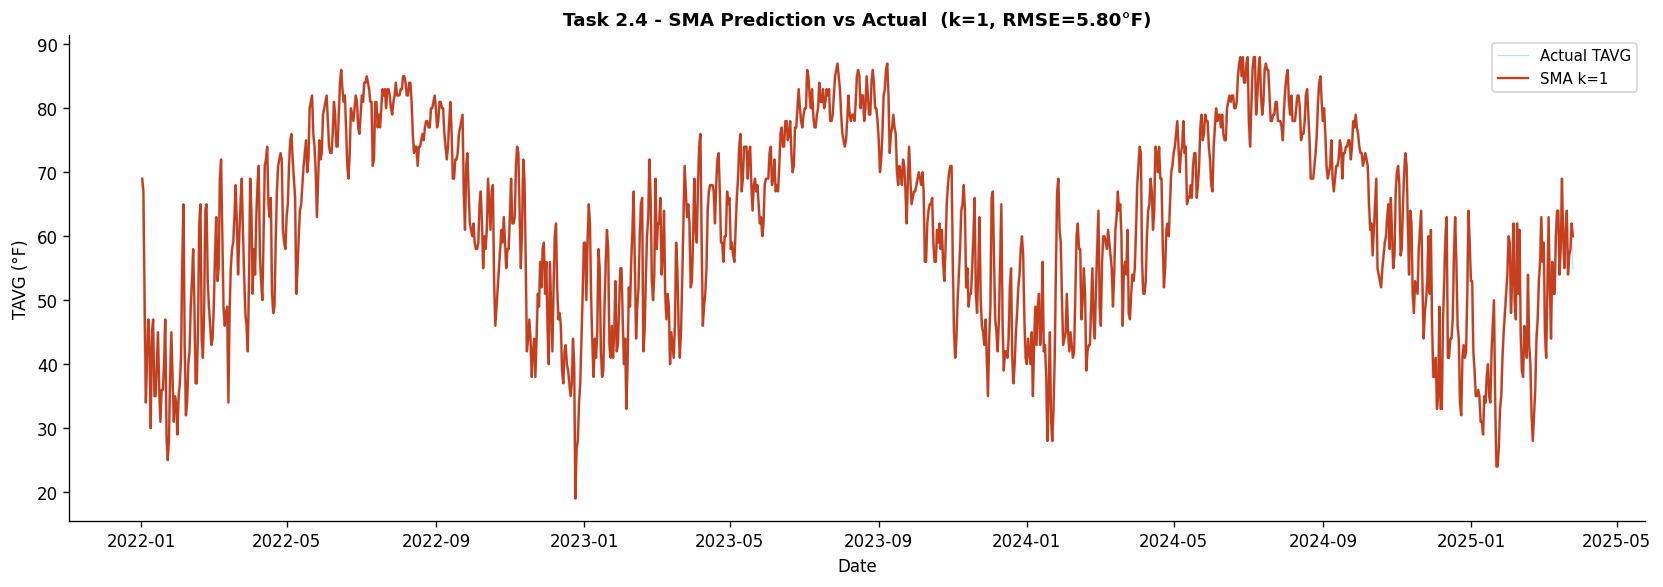


SMA best k=1: RMSE=5.8021°F, MAPE=8.1489%


In [ ]:
k_values  = list(range(1, 31))
rmse_list = []
mape_list = []

for k in k_values:
    pred  = sma_predict(train_vals, k)
    valid = ~np.isnan(pred)
    rmse_list.append(rmse(train_vals[valid], pred[valid]))
    mape_list.append(mape(train_vals[valid], pred[valid]))

best_k         = k_values[np.argmin(rmse_list)]
sma_train_rmse = min(rmse_list)
sma_train_mape = mape_list[best_k - 1]

print(f'Best k by RMSE : k={best_k}  RMSE={sma_train_rmse:.4f}°F')
print(f'Best k by MAPE : k={k_values[np.argmin(mape_list)]}  MAPE={min(mape_list):.4f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(k_values, rmse_list, 'o-', color='#2E86AB', linewidth=1.8, markersize=5)
axes[0].axvline(best_k, color='red', linestyle='--', linewidth=1.5, label=f'Best k={best_k}')
axes[0].set_xlabel('k (window size)'); axes[0].set_ylabel('RMSE (°F)')
axes[0].set_title('Task 2.4 - RMSE vs k', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].plot(k_values, mape_list, 's-', color='#A23B72', linewidth=1.8, markersize=5)
axes[1].axvline(k_values[np.argmin(mape_list)], color='red', linestyle='--',
                linewidth=1.5, label=f'Best k={k_values[np.argmin(mape_list)]}')
axes[1].set_xlabel('k (window size)'); axes[1].set_ylabel('MAPE (%)')
axes[1].set_title('Task 2.4 - MAPE vs k', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('t2_rmse_mape_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

# Best k: predicted vs actual
pred_sma_best = sma_predict(train_vals, best_k)
valid         = ~np.isnan(pred_sma_best)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_train.index, train_vals,               color='lightblue', linewidth=0.7, alpha=0.8, label='Actual TAVG')
ax.plot(ts_train.index[valid], pred_sma_best[valid], color='#C73E1D', linewidth=1.4, label=f'SMA k={best_k}')
ax.set_xlabel('Date'); ax.set_ylabel('TAVG (°F)')
ax.set_title(f'Task 2.4 - SMA Prediction vs Actual  (k={best_k}, RMSE={sma_train_rmse:.2f}°F)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('t2_sma_best_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSMA best k={best_k}: RMSE={sma_train_rmse:.4f}°F, MAPE={sma_train_mape:.4f}%')


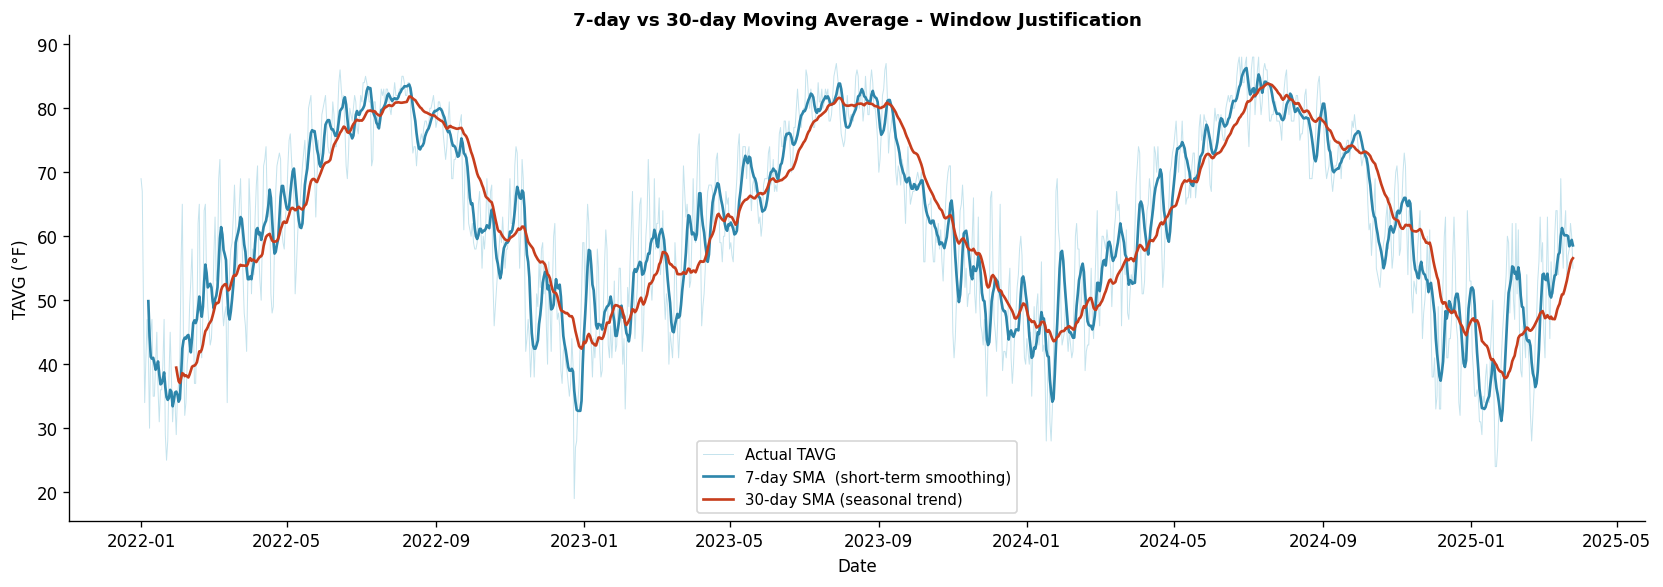

In [3]:
# Visual comparison: 7-day vs 30-day rolling mean on training data
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_train.index, train_vals, color='lightblue', linewidth=0.6, alpha=0.7, label='Actual TAVG')
ax.plot(ts_train.index, pd.Series(train_vals).rolling(7).mean(),  color='#2E86AB', linewidth=1.6, label='7-day SMA  (short-term smoothing)')
ax.plot(ts_train.index, pd.Series(train_vals).rolling(30).mean(), color='#C73E1D', linewidth=1.6, label='30-day SMA (seasonal trend)')
ax.set_xlabel('Date')
ax.set_ylabel('TAVG (°F)')
ax.set_title('7-day vs 30-day Moving Average - Window Justification', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('t2_window_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
# 7-day smooths daily noise while 30-day tracks the underlying seasonal cycle

## Task 2.5 - Comments

The SMA applies equal weight to the k most recent observations. As k increases the prediction smooths out but lags more behind rapid seasonal transitions. Very small k tracks noise closely, while large k is too sluggish for spring/fall transitions.

The RMSE vs k plot shows a clear minimum at the best k. The predicted vs actual plot shows the SMA follows the seasonal shape but consistently lags at transition points - a fundamental limitation of any backward-looking moving average. The model performs best during stable midsummer or midwinter plateaus and worst during the spring warm-up and fall cool-down.
